In [34]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [35]:
from pathlib import Path
import time
import random
import os
import z3
from itertools import product
import time
import random

# Env

In [36]:
def is_out_of_range(y: int, x: int, N:int)->bool:
    return not ((0 <= x < N) and (0 <= y < N))

In [37]:
class Env:
    IS_OUTPUT_FILE = True

    def __init__(self, file_path: str, exp_num: int):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2 * M :]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))

        self.N: int = N
        self.M: int = M
        self.esp: float = ESP
        self.grids: list[list[tuple[int, int]]] = GRID
        self.ans_grid: list[list[int]] = ANS_GRID

        self.total_oil_num: int = sum(len(g) for g in self.grids)
        self.score: int = 10**9

        cnt: int = 0
        for y in range(N):
            for x in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size: int = cnt

        self._sum_oil: int = 0
        self._score: float = 0

        self.plus_coordinates: list[tuple[int, int]] = []
        self.queries1: list[tuple[tuple[int, int], int]] = []
        self.fixed_board: list[list[int]] = [[-1 for _ in range(N)] for _ in range(N)]

        self._out_file_path: Path = Path(f"../out/out{exp_num:0>4}.txt")

        if Env.IS_OUTPUT_FILE:
            if self._out_file_path.exists():
                os.remove(self._out_file_path)
            self._out_file_path.touch()

    def is_ok(self):
        return self._sum_oil == self.total_oil_num

    def query1(self, coordinate) -> int:
        y, x = coordinate
        self._score += 1
        resp: int = self.ans_grid[y][x]
        self.queries1.append((coordinate, resp))
        self.fixed_board[y][x] = resp
        if resp > 0:
            self._sum_oil += resp
            self.plus_coordinates.append(coordinate)
        if Env.IS_OUTPUT_FILE:
            q = "q 1 {} {}".format(coordinate[0], coordinate[1])
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return resp

    def answer(self, coordinates) -> bool:
        is_ok = self.total_oil_num == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        if Env.IS_OUTPUT_FILE:
            q = "a {} {}".format(len(coordinates), " ".join(map(lambda k: "{} {}".format(k[0], k[1]), coordinates)))
            with open(self._out_file_path, mode="+a") as f:
                f.write(q + "\n")
        return is_ok

    def answer_from_board(self, board: list[list[int]]) -> bool:
        has_oils: list[tuple[int, int]] = []
        for y in range(self.N):
            for x in range(self.N):
                if board[y][x] > 0:
                    has_oils.append((y, x))
        return self.answer(has_oils)

    @property
    def query1_count(self) -> int:
        return len(self.queries1)

In [38]:
class BoardSimulator:

    SIMULATE_TIME_OUT = 2.0
    SIMULATE_MAX = 100000
    SIMULATE_MIN = 50
    MIN_INDEX_CANDIDATES = 100

    def __init__(self, env: Env):
        self.env: Env = env

        self.simulate_avg_num: float = 0
        self.simulate_cnt: int = 0

        self._indexes_candidate : list[tuple[int]] = []

    def _search_placement_indexes(self) -> list[list[tuple[int, int]]]:
        """現在の確定盤面に対して配置可能なインデックスを計算する"""

        N: int = self.env.N
        M: int = self.env.M
        f_board: list[list[int]] = self.env.fixed_board
        grids: list[list[tuple[int, int]]] = self.env.grids

        placement_indexes: list[list[tuple[int, int]]] = []
        for m in range(M):
            now_grids: list[tuple[int, int]] = grids[m]
            now_placement_indexes: list[tuple[int, int]] = []
            for y in range(N):
                for x in range(N):
                    flag: bool = True
                    max_diff = -1
                    for coordinate in now_grids:
                        ny, nx = y + coordinate[0], x + coordinate[1]
                        if is_out_of_range(ny, nx, N) or f_board[ny][nx] == 0:
                            flag = False
                            break
                        max_diff = max(max_diff, f_board[ny][nx])
                    if flag:
                        now_placement_indexes.append((y, x))
            placement_indexes.append(now_placement_indexes)

        return placement_indexes

    def _get_indexes_candidate(self):

        M: int = self.env.M

        self._indexes_candidate : list[list[tuple[int ,int]]] = []
        if len(self._indexes_candidate) == 0:
            placement_indexes : list[list[tuple[int, int]]] = self._search_placement_indexes()
            for _ in range(BoardSimulator.MIN_INDEX_CANDIDATES):
                sampling_indexes : list[tuple[int, int]]= []
                for m in range(M):
                    sampling_index: tuple[int, int] = random.choice(placement_indexes[m])
                    sampling_indexes.append(sampling_index)
                self._indexes_candidate.append(sampling_indexes)
            return self._indexes_candidate
        else:
            return self._indexes_candidate

    def _update_indexes_candidate(self, stock_indexes: list[list[tuple[int ,int]]], stock_costs: list[float]):        
        sorted_costs, sorted_indexes = zip(*sorted(zip(stock_costs, stock_indexes)))
        self._indexes_candidate = sorted_indexes[:BoardSimulator.MIN_INDEX_CANDIDATES]

    def _calc_cost_from_simulated_board(self, simulated_board: list[list[int]]) -> float:

        N: int = self.env.N
        f_board: list[list[int]] = self.env.fixed_board

        cost: float = 0
        for y in range(N):
            for x in range(N):
                if f_board[y][x] == -1:
                    continue
                v: int = abs(simulated_board[y][x] - f_board[y][x])
                cost += v
        return cost

    def get_next_coordinate(self) -> tuple[tuple[int, int], None | list[list[int]]]:
        """
        現在の盤面と最も一致している（コストの低い）盤面で、最も正の数である確率が高い座標を返す。
        """

        start_time: float = time.time()

        N: int = self.env.N
        M: int = self.env.M
        f_board: list[list[int]] = self.env.fixed_board
        grids: list[list[tuple[int, int]]] = self.env.grids

        plus_count_board: list[list[float]] = [[0.0 for _ in range(N)] for _ in range(N)]
        ans_board: list[list[int]] = None
        only_one_ans_board: bool = False

        placement_indexes: dict[int, list[tuple[int, int]]] = self._search_placement_indexes()
        indexes_candidate = self._get_indexes_candidate()

        stock_indexes :list[list[tuple[int ,int]]] = []
        stock_costs : list[float] = []

        random_index_prob = max(1.0 / M * 1.74, 1.0 - (self.simulate_cnt / (N**2 / 2.83)))
        for simulate_num in range(BoardSimulator.SIMULATE_MAX):
            now_board: list[list[int]] = [[0 for _ in range(N)] for _ in range(N)]
            sampling_indexes = list(random.choice(indexes_candidate))
            for m in range(M):
                if random.random() < random_index_prob:
                    sampling_indexes[m] = random.choice(placement_indexes[m])
            for m in range(M):
                sampling_index = sampling_indexes[m]
                for y, x in grids[m]:
                    ny, nx = y + sampling_index[0], x + sampling_index[1]
                    now_board[ny][nx] += 1
            cost: float = self._calc_cost_from_simulated_board(now_board)
            stock_indexes.append(sampling_indexes)
            stock_costs.append(cost)
            
            if cost == 0:
                if ans_board is None:
                    ans_board = now_board
                    only_one_ans_board = True
                else:
                    only_one_ans_board = False
            for y in range(N):
                for x in range(N):
                    if now_board[y][x] > 0:
                        plus_count_board[y][x] +=  now_board[y][x] / (cost + 1)
            if (simulate_num > BoardSimulator.SIMULATE_MIN) and time.time() - start_time > BoardSimulator.SIMULATE_TIME_OUT / N**2:
                break
        
        self._update_indexes_candidate(stock_indexes, stock_costs)

        max_coordinate: tuple[int, int] = (-1, -1)
        max_cnt: int = -1
        for y in range(N):
            for x in range(N):
                if f_board[y][x] != -1:
                    continue
                cnt = plus_count_board[y][x]
                if cnt > max_cnt:
                    max_cnt = cnt
                    max_coordinate = (y, x)

        self.simulate_cnt += 1

        if only_one_ans_board:
            return max_coordinate, ans_board
        else:
            return max_coordinate, None

In [39]:
# --------------------  #
class SMTSolver():

    def __init__(self, env:Env):
        placements_grid_set = {}
        for m in range(env.M):
            now_grid_set = [[set() for _ in range(env.N)] for _ in range(env.N)]
            target_grids = env.grids[m]
            for x in range(env.N):
                for y in range(env.N):
                    tmp_grids = []
                    is_ok = True
                    for coordinate in target_grids:
                        ny, nx = coordinate[0] + y, coordinate[1] + x
                        if is_out_of_range(ny, nx, env.N):
                            is_ok = False
                            break
                        tmp_grids.append((ny, nx))
                    if not is_ok:
                        continue
                    for coordinate in tmp_grids:
                        ty, tx = coordinate
                        now_grid_set[ty][tx].add((y, x))
            placements_grid_set[m] = now_grid_set
        
        self.placements_grid_set = placements_grid_set
        self.env = env

    def solve(self):
        z3_solver = z3.Solver()
        env = self.env

        # 配列外参照にならないインデックスを追加
        var_x = {}
        for m in range(env.M):
            for y, x in product(list(range(env.N)), list(range(env.N))):
                target_grids = env.grids[m]
                flag = True
                for coordinate in target_grids:
                    ny, nx = coordinate[0] + y, coordinate[1] + x
                    if is_out_of_range(ny, nx, env.N):
                        flag = False
                        break
                if flag:
                    var_x[m, y, x] = z3.Bool(f"var_x{m, y, x}")

        # 配置はどれか1つを選択しなければならない
        for m in range(env.M):
            now_vars = []
            for y, x in product(list(range(env.N)), list(range(env.N))):
                ind = y*env.N + x
                if (m, y, x) in var_x:
                    now_vars.append(var_x[m, y, x])
            z3_solver.add(z3.Sum(now_vars) == 1)

        # 配置した箇所に対応するグリッドが加算される
        set_coordinates = set([coordinate for coordinate, resp in env.queries1])
        for y, x in product(list(range(env.N)), list(range(env.N))):
            bool_vars = []
            for m in range(env.M):
                for ty, tx in self.placements_grid_set[m][y][x]:
                    if (m, ty, tx) in var_x:
                        bool_vars.append(var_x[m ,ty, tx])
            if (y, x) in set_coordinates:
                for query in env.queries1:
                    coordinate, resp = query
                    if coordinate == (y, x):
                        z3_solver.add(z3.Sum(bool_vars) == resp)
        
        # 解を求める
        z3_solver.set('timeout', 300)
        if not z3_solver.check() == z3.sat:
            return None
        model = z3_solver.model()

        placement_ans = []
        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            if (m, y, x) in var_x:
                if model.eval(var_x[m, y, x]):
                    placement_ans.append((m, y, x))

        point_ans = set()
        for m, y, x in placement_ans:
            target_grids = env.grids[m]
            for coordinate in target_grids:
                ny, nx = coordinate[0] + y, coordinate[1] + x
                point_ans.add((ny, nx))

        return point_ans

# Run

In [40]:
class Evaluator:

    def __init__(self):
        self.scores = []
        self.ans_points = []
        self.board_sizes = []

    def add_result(self, score, ans_point, board_size):
        self.scores.append(score)
        self.ans_points.append(ans_point)
        self.board_sizes.append(board_size)

In [41]:
def solve1(env: Env):
    
    SMT_TIME_OUT = 2.0
    smt_level = [0.075, 0.125, 0.2, 0.3, 0.55, 1]

    BoardSimulator.SIMULATE_TIME_OUT = 0.5
    BoardSimulator.SIMULATE_MIN = 10

    start_time = time.time()
    board_simulator = BoardSimulator(env)
    for i in range(500):
        if env.is_ok():
            env.answer(env.plus_coordinates)
            break
        coordinate, ans_board = board_simulator.get_next_coordinate()
        if (time.time() - start_time < SMT_TIME_OUT) and i >= env.N**2 * smt_level[0]:
            smt_solver = SMTSolver(env)
            ans_points = smt_solver.solve()
            if ans_points:
                print("SOLVE")
                if env.answer(ans_points):
                    print("OK!!!")
                    break
            else:
                print("NONE")
            smt_level.pop(0)
        elif ans_board is not None:
            if env.answer_from_board(ans_board):
                break
        resp = env.query1(coordinate)

def solve2(env: Env):
    
    board_simulator = BoardSimulator(env)
    for i in range(500):
        if env.is_ok():
            env.answer(env.plus_coordinates)
            break
        coordinate, ans_board = board_simulator.get_next_coordinate()
        if ans_board is not None:
            if env.answer_from_board(ans_board):
                break
        resp = env.query1(coordinate)

def solve(env: Env):
    # if env.M <= 2 or (env.N <= 15 and env.M <= 3):
    #     solve1(env)
    # else:
    solve2(env)

In [42]:
TEST_CASE_NUM = 100

In [43]:
evaluator = Evaluator()

def main():
    random.seed(0)
    for test_num in range(TEST_CASE_NUM):
        with timer(f"===== {test_num+1}/{TEST_CASE_NUM} ====="):
            env = Env(file_path = Path(f"../in/{test_num:0>4}.txt"), exp_num=test_num)
            solve(env)
            evaluator.add_result(env.score, env.ans_point_size, env.N**2)
            print(f"score:{env.score}")
main()

score:32
[===== 1/100 =====] done in 1000.0 msec
score:31
[===== 2/100 =====] done in 861.3 msec
score:28
[===== 3/100 =====] done in 767.0 msec
score:37
[===== 4/100 =====] done in 1030.9 msec
score:32
[===== 5/100 =====] done in 850.8 msec
score:12
[===== 6/100 =====] done in 338.2 msec
score:6
[===== 7/100 =====] done in 163.7 msec
score:10
[===== 8/100 =====] done in 311.2 msec
score:21
[===== 9/100 =====] done in 558.8 msec
score:30
[===== 10/100 =====] done in 823.3 msec
score:33
[===== 11/100 =====] done in 922.6 msec
score:28
[===== 12/100 =====] done in 747.1 msec
score:11
[===== 13/100 =====] done in 307.9 msec
score:34
[===== 14/100 =====] done in 915.3 msec
score:27
[===== 15/100 =====] done in 747.0 msec
score:28
[===== 16/100 =====] done in 761.0 msec
score:29
[===== 17/100 =====] done in 785.9 msec
score:37
[===== 18/100 =====] done in 1020.5 msec
score:28
[===== 19/100 =====] done in 751.3 msec
score:26
[===== 20/100 =====] done in 710.2 msec
score:7
[===== 21/100 =====

# Evaluate

変化なし 82.23
横の隣接スコアを採用 82.96
中央スコアを採用 82.03

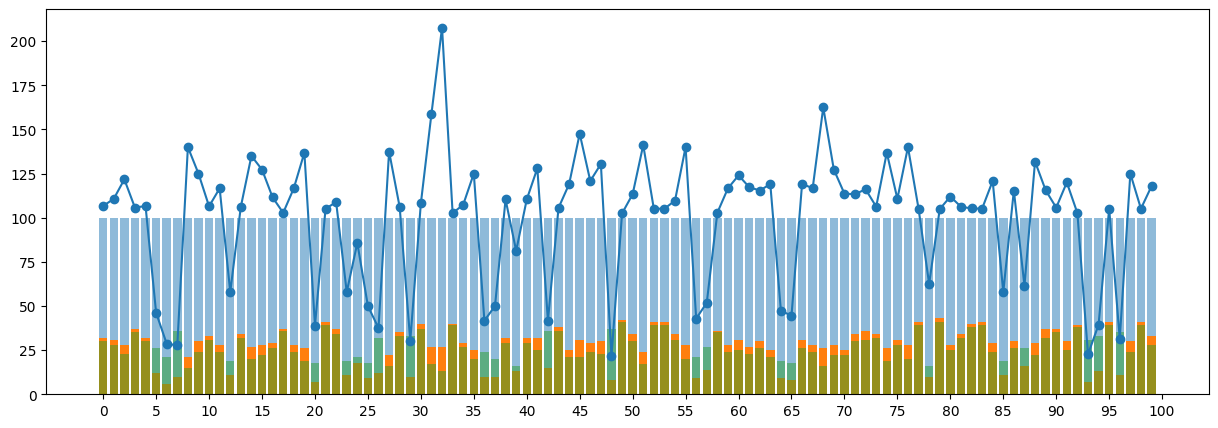

4.882476887912505
26.74


In [44]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 5))
x = list(range(TEST_CASE_NUM))
plt.bar(x, evaluator.board_sizes, alpha=0.5)
plt.bar(x, evaluator.scores)
plt.bar(x, evaluator.ans_points, alpha=0.5)
plt.plot(x, np.array(evaluator.scores) / np.array(evaluator.ans_points) * 100, marker="o")
plt.xticks(range(0, len(evaluator.scores)+1, 5))
plt.show()


print(sum(1 / score for score in evaluator.scores))
print(sum(evaluator.scores) / len(evaluator.scores))